# Manuscript figure assembly

Final step of the pipeline. Builds the composite figures the manuscript uses, from outputs the
earlier notebooks already wrote, so that no figure in the paper is a hand-made asset that can
silently go stale when an analysis is re-run.

This replaces three manually assembled files (`FIG 2 HEATMAPS.pdf`, `features_SBO.pdf` and
`Confusion_Matrices.pdf`), one of which had already drifted out of date: it still carried the
per-model labels from before `04_heatmaps.ipynb` switched them from mean signed error to CCC.

Runs last because it needs output from both `04_heatmaps.ipynb` (the three relative-error
heatmaps) and `05_phenotype_phase_plane.ipynb` (the glucose-uptake curve).

| Output | Replaces | Sources |
|---|---|---|
| `Fig_features_SBO.pdf` | `manuscript/figures/features_SBO.pdf` | `Score.csv`, `SBO_Reaction_Matrix.csv` (01, 02) |
| `Fig_growth_composite.pdf` | `manuscript/figures/FIG 2 HEATMAPS.pdf` | `Heatmap_*.pdf` (04), `qGlc_vs_mu.pdf` (05) |
| `Fig_confusion_matrices.pdf` | `supplementary/figures/Confusion_Matrices.pdf` | `GeneEssentiality.csv` (06) |

The two data-driven figures are **re-plotted from the CSVs** rather than stitched from images, so
they are reproducible and restyled to match the rest of the paper. The growth composite is stitched
at the PDF level with PyMuPDF, which keeps every panel vector rather than rasterising it.

In [1]:
import os

import fitz                      # PyMuPDF - vector-preserving PDF composition
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

TABLES_DIR = os.path.join("..", "results", "tables")
FIGURES_DIR = os.path.join("..", "results", "figures")

# Publication order, used by the structural figure and Table S2. The functional analyses use
# the seven-model canonical order instead; both appear in the paper.
ALL_MODELS = ["iYO844", "iBsu1103", "iBsu1103v2", "iBsu1147", "eciYO844",
              "iBsu1209", "iBB1018", "iBsu1147R", "ecBSU1", "Submodel"]

MUTED, GRID_COLOR, INK = "#52514e", "#e1e0d9", "#0b0b0b"

plt.rcParams.update({
    "font.size": 13, "font.family": "sans-serif", "font.sans-serif": ["Arial"],
    # Math in labels ($\mu$, h$^{-1}$) otherwise renders in matplotlib's default DejaVu while
    # the surrounding text is Arial, so one axis label ends up in two typefaces.
    "mathtext.fontset": "custom",
    "mathtext.rm": "Arial",
    "mathtext.it": "Arial:italic",
    "mathtext.bf": "Arial:bold",
    "axes.labelsize": 14, "axes.titlesize": 15, "legend.fontsize": 12,
    "axes.linewidth": 1.2, "axes.edgecolor": "#c3c2b7", "pdf.fonttype": 42,
})


def style(ax, axis="y"):
    ax.grid(True, axis=axis, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors=MUTED)
    ax.yaxis.label.set_color(MUTED)
    ax.xaxis.label.set_color(MUTED)


def panel_letter(ax, letter, x=-0.09, y=1.03):
    ax.text(x, y, letter, transform=ax.transAxes, fontsize=21, fontweight="bold",
            ha="left", va="bottom", color=INK, fontfamily="Arial")


print(f"[INFO] reading from {TABLES_DIR} and {FIGURES_DIR}")

[INFO] reading from ..\results\tables and ..\results\figures


## Figure 2 - structural features and SBO composition

Panel A: the three size measures with the MEMOTE score on a secondary axis. Panel B: SBO composition as 100% stacked bars, with the five transport-related terms pooled and the tail collected as other reactions.

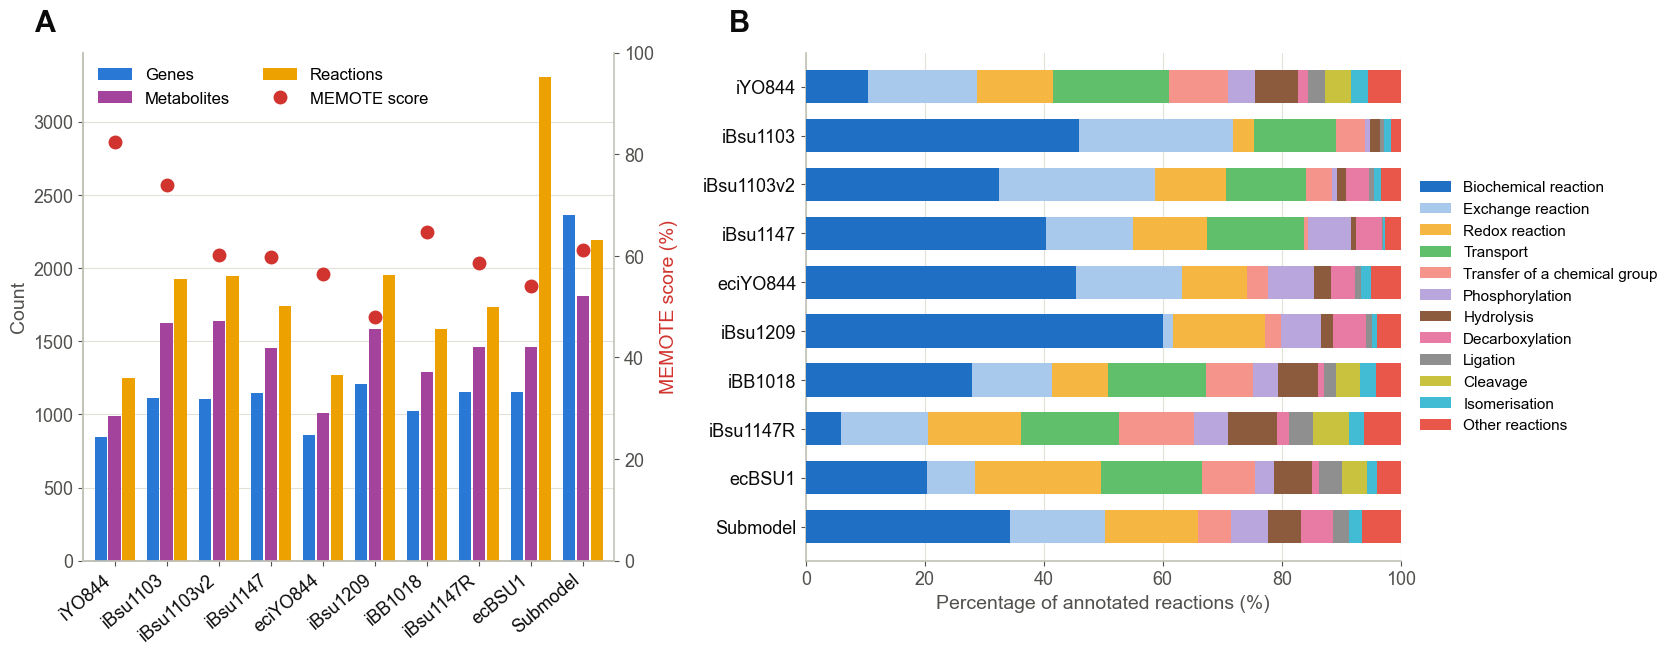

[INFO] Figure saved to ..\results\figures\Fig_features_SBO.pdf


In [2]:
FEATURE_COLORS = {"Genes": "#2a78d6", "Metabolites": "#a3439b", "Reactions": "#eda100"}
SCORE_COLOR = "#d1342f"

TRANSPORT_TERMS = ["Symporter-mediated transport", "Active transport", "Passive transport",
                   "Antiporter-mediated transport", "Translocation reaction"]
SBO_ORDER = ["Biochemical reaction", "Exchange reaction", "Redox reaction", "Transport",
             "Transfer of a chemical group", "Phosphorylation", "Hydrolysis",
             "Decarboxylation", "Ligation", "Cleavage", "Isomerisation", "Other reactions"]
SBO_COLORS = ["#1f6fc4", "#a8c8ec", "#f5b642", "#5fbf6a", "#f4948b", "#b9a6dd",
              "#8c5a3c", "#e87ba4", "#8f8f8f", "#c9c23f", "#42bcd4", "#e8574a"]


def sbo_percentages():
    """Per-model SBO composition in %, with transport pooled and the tail collapsed."""
    sbo = pd.read_csv(os.path.join(TABLES_DIR, "SBO_Reaction_Matrix.csv")).set_index("Model")
    grouped = pd.DataFrame(index=sbo.index)
    for term in SBO_ORDER:
        if term == "Transport":
            grouped[term] = sbo[[c for c in TRANSPORT_TERMS if c in sbo.columns]].sum(axis=1)
        elif term != "Other reactions":
            grouped[term] = sbo[term]
    grouped["Other reactions"] = sbo.sum(axis=1) - grouped.sum(axis=1)
    return 100 * grouped.div(sbo.sum(axis=1), axis=0)


def figure_features_sbo(out_path):
    score = pd.read_csv(os.path.join(TABLES_DIR, "Score.csv")).set_index("Model").loc[ALL_MODELS]
    pct = sbo_percentages().loc[ALL_MODELS]

    fig = plt.figure(figsize=(17, 6.6))
    # Generous wspace: panel A carries a right-hand MEMOTE axis and panel B a left-hand column
    # of model names, and the two collide at the default spacing.
    gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.12], wspace=0.34)
    ax_a, ax_b = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

    x = np.arange(len(ALL_MODELS))
    slot, width = 0.8 / 3, (0.8 / 3) * 0.88
    for i, feature in enumerate(FEATURE_COLORS):
        ax_a.bar(x + (i - 1) * slot, score[feature], width, label=feature,
                 color=FEATURE_COLORS[feature], linewidth=0, zorder=3)
    ax_a.set_ylabel("Count")
    ax_a.set_xticks(x)
    ax_a.set_xticklabels(ALL_MODELS, rotation=40, ha="right")
    ax_a.set_xlim(-0.6, len(ALL_MODELS) - 0.4)
    style(ax_a)
    for label in ax_a.get_xticklabels():
        label.set_color(INK)

    ax_score = ax_a.twinx()
    ax_score.plot(x, score["Score"], linestyle="none", marker="o", markersize=9,
                  color=SCORE_COLOR, zorder=5)
    ax_score.set_ylabel("MEMOTE score (%)")
    ax_score.set_ylim(0, 100)
    ax_score.spines["top"].set_visible(False)
    ax_score.tick_params(colors=MUTED)
    ax_score.yaxis.label.set_color(SCORE_COLOR)

    handles, labels = ax_a.get_legend_handles_labels()
    handles.append(plt.Line2D([], [], linestyle="none", marker="o", markersize=9,
                              color=SCORE_COLOR))
    labels.append("MEMOTE score")
    ax_a.legend(handles, labels, frameon=False, loc="upper left", ncol=2)
    panel_letter(ax_a, "A")

    # First model at the top, so the bars read in the same order as the panel A categories.
    y = np.arange(len(ALL_MODELS))[::-1]
    left = np.zeros(len(ALL_MODELS))
    for term, colour in zip(SBO_ORDER, SBO_COLORS):
        ax_b.barh(y, pct[term], 0.68, left=left, color=colour, linewidth=0, zorder=3)
        left += pct[term].to_numpy()
    ax_b.set_xlabel("Percentage of annotated reactions (%)")
    ax_b.set_xlim(0, 100)
    ax_b.set_yticks(y)
    ax_b.set_yticklabels(ALL_MODELS)
    ax_b.set_ylim(-0.7, len(ALL_MODELS) - 0.3)
    style(ax_b, axis="x")
    for label in ax_b.get_yticklabels():
        label.set_color(INK)
    ax_b.legend(handles=[Patch(facecolor=c, label=t) for t, c in zip(SBO_ORDER, SBO_COLORS)],
                frameon=False, loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=11)
    panel_letter(ax_b, "B", x=-0.13)

    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print(f"[INFO] Figure saved to {out_path}")


figure_features_sbo(os.path.join(FIGURES_DIR, "Fig_features_SBO.pdf"))

## Gene essentiality confusion matrices

One matrix per model, rows = experimental call, columns = prediction. Shading is normalised within rows because the classes differ several-fold in size.

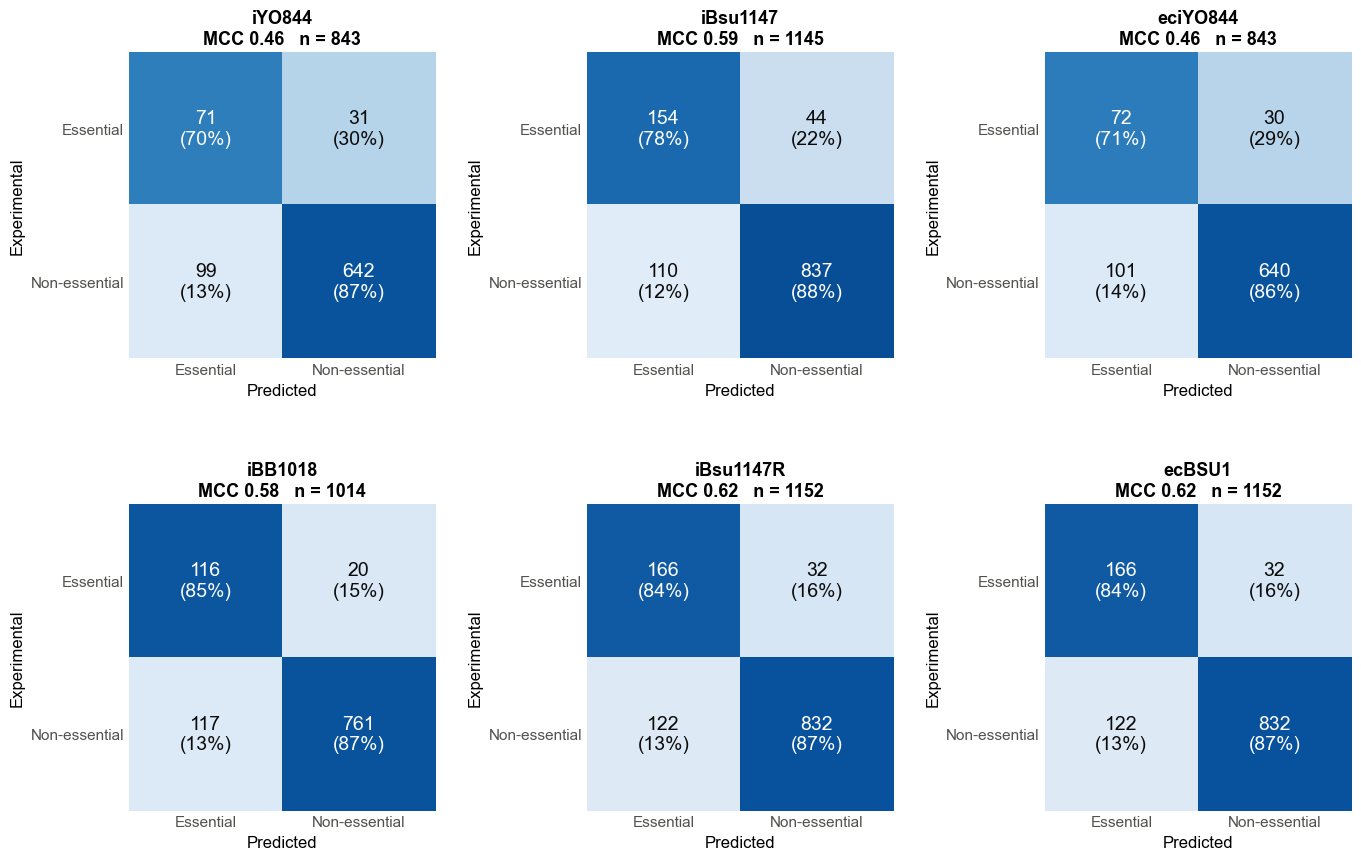

[INFO] Figure saved to ..\results\figures\Fig_confusion_matrices.pdf


In [3]:
def confusion_matrix_grid(counts, out_path, class_labels, ncols=3):
    """Grid of confusion matrices, one per model; rows = experimental, columns = predicted.

    `counts` maps model name -> (TP, FP, TN, FN, MCC). Used for both binary classification
    analyses in the paper so they are drawn identically and can be read side by side.

    Shading is normalised within each row; both datasets are several-fold imbalanced.
    """
    models = [m for m in ALL_MODELS if m in counts]
    nrows = int(np.ceil(len(models) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.5 * nrows), squeeze=False)

    for ax, model in zip(axes.ravel(), models):
        tp, fp, tn, fn, mcc = counts[model]
        matrix = np.array([[tp, fn], [fp, tn]], dtype=float)
        shares = matrix / matrix.sum(axis=1, keepdims=True)

        ax.imshow(shares, cmap="Blues", vmin=0, vmax=1)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{int(matrix[i, j])}\n({shares[i, j]:.0%})",
                        ha="center", va="center", fontsize=14,
                        color="white" if shares[i, j] > 0.55 else INK)
        ax.set_xticks([0, 1], class_labels, fontsize=11)
        ax.set_yticks([0, 1], class_labels, fontsize=11)
        ax.set_xlabel("Predicted", fontsize=12)
        ax.set_ylabel("Experimental", fontsize=12)
        ax.set_title(f"{model}\nMCC {mcc:.2f}   n = {int(matrix.sum())}",
                     fontweight="bold", fontsize=13)
        ax.tick_params(length=0, colors=MUTED)
        for spine in ax.spines.values():
            spine.set_visible(False)

    for ax in axes.ravel()[len(models):]:
        ax.set_visible(False)

    fig.tight_layout(h_pad=2.4, w_pad=1.8)
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print(f"[INFO] Figure saved to {out_path}")


essentiality = pd.read_csv(os.path.join(TABLES_DIR, "GeneEssentiality.csv")).set_index("model")
confusion_matrix_grid(
    {m: (r["TP"], r["FP"], r["TN"], r["FN"], r["MCC"]) for m, r in essentiality.iterrows()},
    os.path.join(FIGURES_DIR, "Fig_confusion_matrices.pdf"),
    class_labels=["Essential", "Non-essential"],
    ncols=3,
)

## Carbon-source utilization confusion matrices

Same grid, same function, so the two classification analyses are drawn identically.

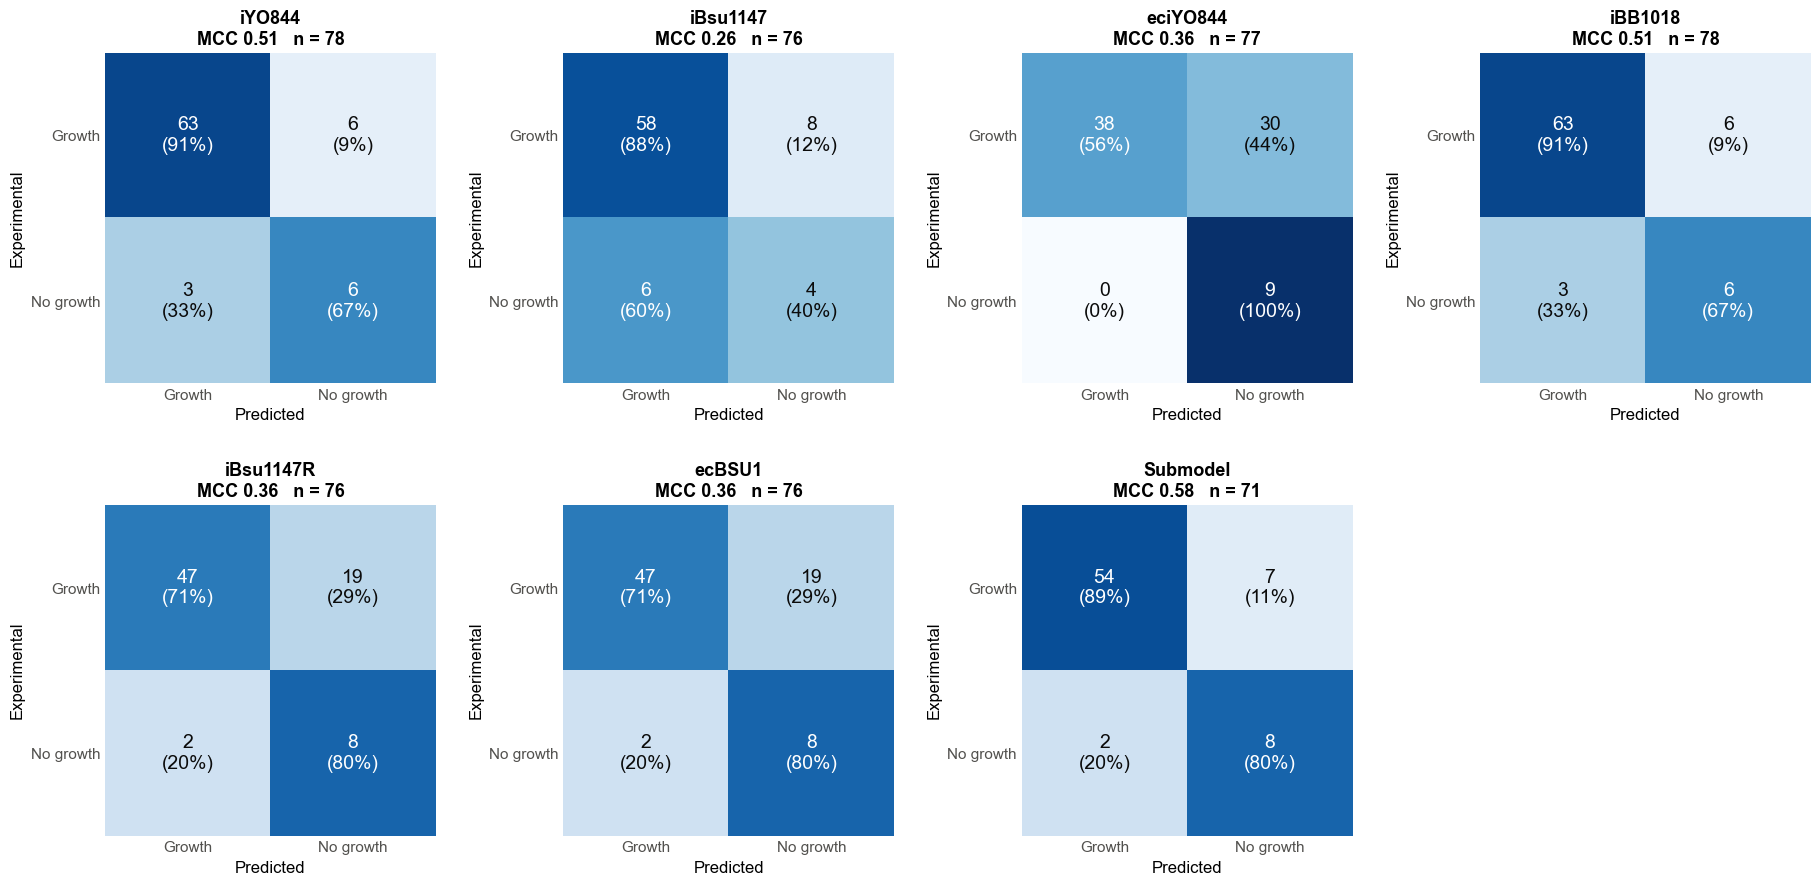

[INFO] Figure saved to ..\results\figures\Fig_carbon_utilization_matrices.pdf


In [4]:
utilization = pd.read_csv(os.path.join(TABLES_DIR, "carbon_utilization_Summary.csv")) \
                .set_index("model")

# Four columns rather than three: seven models leave a single empty slot in a 4x2 grid instead
# of two in a 3x3 one.
confusion_matrix_grid(
    {m: (r["TP"], r["FP"], r["TN"], r["FN"], r["MCC"]) for m, r in utilization.iterrows()},
    os.path.join(FIGURES_DIR, "Fig_carbon_utilization_matrices.pdf"),
    class_labels=["Growth", "No growth"],
    ncols=4,
)

## Growth composite (manuscript Figure 3)

The three relative-error heatmaps, stitched at the PDF level with PyMuPDF because seaborn clustermaps own their figure and cannot be drawn into another one's subplot. Stitching keeps every panel vector.

In [5]:
def figure_growth_composite(out_path):
    """The three relative-error heatmaps: A and B side by side, C centred below.

    Stitched at the PDF level because seaborn clustermaps own their figure and cannot be drawn
    into another one's subplot. Each panel is scaled to its cell at its own aspect ratio.
    """
    sources = [("A", "Heatmap_Chubukov_2013_results.pdf"),
               ("B", "Heatmap_Dauner_2001_results.pdf"),
               ("C", "Heatmap_Dauner_2001caa3KO_results.pdf")]

    pages = [(letter, fitz.open(os.path.join(FIGURES_DIR, name))) for letter, name in sources]
    cell_w = max(doc[0].rect.width for _, doc in pages)
    cell_h = max(doc[0].rect.height for _, doc in pages)
    pad, label_pad = 18, 26

    out = fitz.open()
    page = out.new_page(width=2 * cell_w + 3 * pad,
                        height=2 * (cell_h + label_pad) + 3 * pad)

    # Row 0 holds A and B; C is centred on row 1 rather than left-aligned under a blank cell.
    for (letter, doc), (col, row_i) in zip(pages, [(0, 0), (1, 0), (0.5, 1)]):
        x0 = pad + col * (cell_w + pad)
        y0 = pad + row_i * (cell_h + label_pad + pad) + label_pad
        src = doc[0].rect
        scale = min(cell_w / src.width, cell_h / src.height)
        w, h = src.width * scale, src.height * scale
        origin_x, origin_y = x0 + (cell_w - w) / 2, y0 + (cell_h - h) / 2
        page.show_pdf_page(fitz.Rect(origin_x, origin_y, origin_x + w, origin_y + h), doc, 0)
        page.insert_text((x0, y0 - 8), letter, fontname="Helvetica-Bold", fontsize=22)

    out.save(out_path)
    out.close()
    for _, doc in pages:
        doc.close()
    print(f"[INFO] Figure saved to {out_path}")


figure_growth_composite(os.path.join(FIGURES_DIR, "Fig_growth_composite.pdf"))
print("\n[OK] all manuscript composites rebuilt from pipeline output")

[INFO] Figure saved to ..\results\figures\Fig_growth_composite.pdf

[OK] all manuscript composites rebuilt from pipeline output
